# Nonogram Generator - Commandavid

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

def imagen_a_matriz_binaria(ruta_imagen, size = 90, umbral=None):

    img = Image.open(ruta_imagen).convert("L")

    img_resized = img.resize((size, size))
    img_array = np.array(img_resized, dtype=np.float32)

    if umbral is None:
        umbral = np.mean(img_array)

    matriz_binaria = (img_array < umbral).astype(int)

    return matriz_binaria

def nonograma(ruta_imagen, n = 45, dibujar = True):

    matriz = imagen_a_matriz_binaria(ruta_imagen, n)

    pistas_columnas = []
    pistas_filas = []

    current = 0
    count = 0

    for i,fila in enumerate(matriz):
        pista = []
        for j,celda in enumerate(fila):
            if current == 0:
                if celda:
                    current = 1
                    count = 1
            else:
                if celda:
                    count += 1
                else:
                    current = 0
                    pista.append(count)
                    count = 0
        pistas_filas.append(pista)

    current = 0
    count = 0

    for i in range(n):
        pista = []
        for j in range(n):
            if current == 0:
                if matriz[j][i]:
                    current = 1
                    count = 1
            else:
                if matriz[j][i]:
                    count += 1
                else:
                    current = 0
                    pista.append(count)
                    count = 0
        pistas_columnas.append(pista)

    escala = 2
    fig, ax = plt.subplots(figsize=(10*escala, 10*escala), dpi=100*escala)

    ax.imshow(np.ones((n,n)), cmap='gray_r', interpolation='none')

    if dibujar:
        ax.imshow(matriz, cmap='gray_r', interpolation='none')

    ax.set_xticks(np.arange(-0.5, n, 1))
    ax.set_yticks(np.arange(-0.5, n, 1))
    ax.grid(True, color='black', linewidth=0.5)

    ax.set_xticklabels([])
    ax.set_yticklabels([])

    ax.set_xlim(-0.5, n - 0.5)
    ax.set_ylim(n - 0.5, -0.5)

    for i, num in enumerate(pistas_filas):
        ax.text(-2, i, str(num),
                va='center', ha='right',
                fontsize=6*escala, color='white')

    for j, num in enumerate(pistas_columnas):
        ax.text(j, -2, str(num),
                va='bottom', ha='center',
                rotation=90,
                fontsize=6*escala, color='white')

    plt.tight_layout()
    plt.savefig('nonogram.jpeg', dpi=400*escala, bbox_inches='tight', pad_inches=0.1)
    plt.show()

### Ejemplo de uso:

Change the route so it matches your images route

run nonograma(route, N, draw_solution)

    - route [String] : the route to your image
    - N [int] : the number of rows you want your nonogram to have (it is a square nonogram, NxN)
    - draw_solution [bool] : False if you want your nonogram empty to solve, True if you want to draw the solution



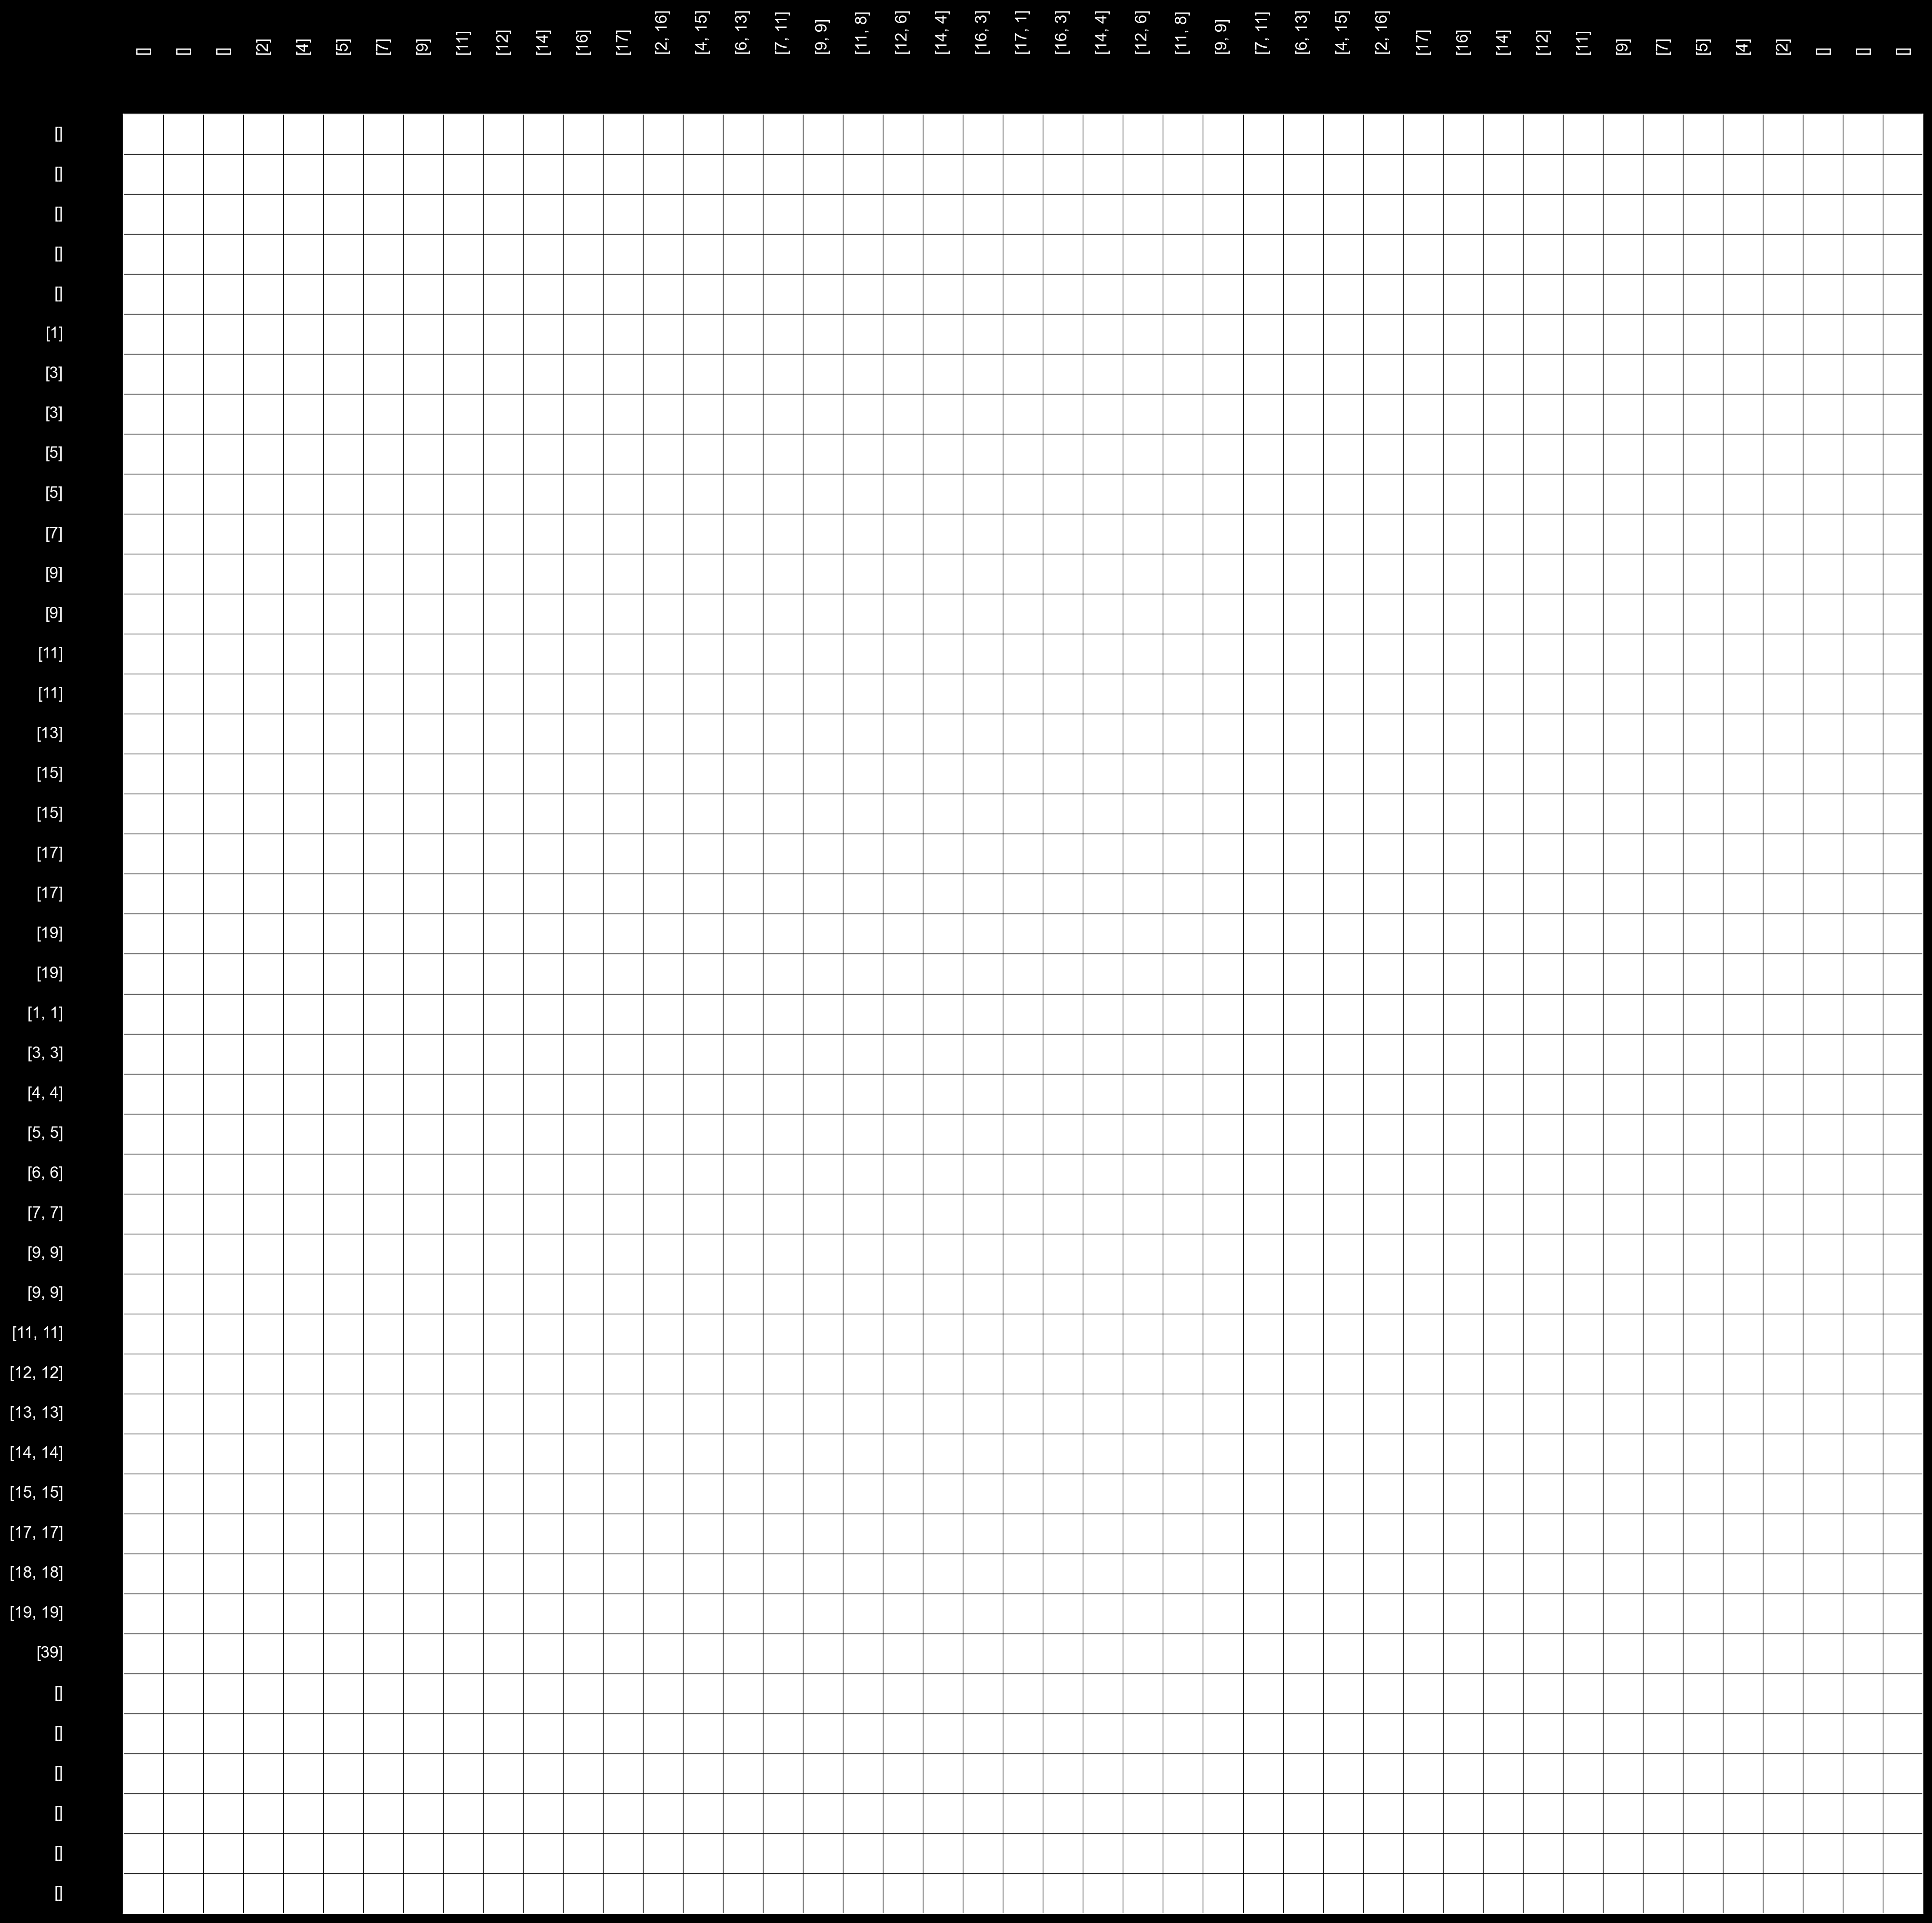

In [3]:
route = "image.jpg"

nonograma(route,45, False)